# P-Adic Quadtree: Build, Inspect, Visualize

Complete workflow:
1. Build and cache quadtree
2. Inspect tree structure
3. Visualize p-adic form

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from collections import deque

sys.path.insert(0, str(Path.cwd().parent))
padic_path = '/Volumes/Fangorn/padic_fractal_analysis/src'
sys.path.insert(0, padic_path)

from padic import preprocessing, quadtree

CACHE_DIR = Path('/Volumes/Fangorn/padic_fractal_analysis/cache')
CACHE_DIR.mkdir(exist_ok=True)

QUADTREE_CACHE = CACHE_DIR / 'quadtree.pkl'
DEM_CACHE = CACHE_DIR / 'dem_clean.npy'

print("✓ Imports successful")

✓ Imports successful


## Step 1: Build and Cache Quadtree

In [2]:
# Check if already cached
if QUADTREE_CACHE.exists() and DEM_CACHE.exists():
    print("Loading cached quadtree...")
    with open(QUADTREE_CACHE, 'rb') as f:
        qtree = pickle.load(f)
    dem_clean = np.load(DEM_CACHE)
    print(f"✓ Loaded cached: qtree(depth={qtree.max_depth}), dem{dem_clean.shape}")
else:
    print("Building new quadtree...")
    # Load DEM
    data_dir = Path('/Volumes/Fangorn/padic_fractal_analysis/data')
    dem_file = list(data_dir.glob('*.tif'))[0]
    print(f"Loading: {dem_file.name}")

    dem, metadata = preprocessing.load_dem(str(dem_file))
    dem_clean, _ = preprocessing.preprocess_dem(dem)
    print(f"DEM shape: {dem_clean.shape}")

    # Build quadtree
    print("Building quadtree (this may take a few minutes)...")
    qtree = quadtree.PadicQuadtree(dem_clean)
    print(f"✓ Built: max_depth={qtree.max_depth}")

    # Cache
    print("Caching to disk...")
    np.save(DEM_CACHE, dem_clean)
    with open(QUADTREE_CACHE, 'wb') as f:
        pickle.dump(qtree, f)
    print(f"✓ Cached to {CACHE_DIR}")

Building new quadtree...
Loading: JEZ_ctx_B_soc_008_DTM_MOLAtopography_DeltaGeoid_20m_Eqc_latTs0_lon0.tif
DEM shape: (1512, 1596)
Building quadtree (this may take a few minutes)...
Building quadtree from 1512×1596 DEM...
✓ Built tree with max_depth=11
✓ Built: max_depth=11
Caching to disk...
✓ Cached to /Volumes/Fangorn/padic_fractal_analysis/cache


## Step 2: Inspect Quadtree Structure

In [3]:
print("\n" + "="*80)
print("QUADTREE STRUCTURE ANALYSIS")
print("="*80)

root = qtree.root
print(f"\nRoot Node:")
print(f"  Level: {root.level}")
print(f"  Bounds: {root.bounds}")
print(f"  Num pixels: {root.num_pixels}")
print(f"  Num children: {len(root.children)}")
print(f"  Elevation mean: {root.elevation_mean:.2f}")
print(f"  Elevation variance: {root.elevation_variance:.6f}")
print(f"  Roughness: {root.roughness:.6f}")

# Count nodes at each level
print(f"\nLevel Distribution:")
level_info = {}
queue = deque([root])

while queue:
    node = queue.popleft()
    if node.level not in level_info:
        level_info[node.level] = {'count': 0, 'variances': [], 'num_pixels': []}
    
    level_info[node.level]['count'] += 1
    level_info[node.level]['variances'].append(node.elevation_variance)
    level_info[node.level]['num_pixels'].append(node.num_pixels)
    
    for child in node.children:
        queue.append(child)

print("\nLevel | Count | Avg Var | Std Var | Min Pix | Max Pix | Avg Pix")
print("-" * 70)
for level in sorted(level_info.keys()):
    info = level_info[level]
    count = info['count']
    variances = np.array(info['variances'])
    num_pixels = np.array(info['num_pixels'])
    
    avg_var = np.mean(variances)
    std_var = np.std(variances)
    min_pix = np.min(num_pixels)
    max_pix = np.max(num_pixels)
    avg_pix = np.mean(num_pixels)
    
    print(f"{level:5d} | {count:5d} | {avg_var:7.6f} | {std_var:7.6f} | {min_pix:7d} | {max_pix:7d} | {avg_pix:7.1f}")


QUADTREE STRUCTURE ANALYSIS

Root Node:
  Level: 0
  Bounds: (0, 1512, 0, 1596)
  Num pixels: 2413152
  Num children: 4
  Elevation mean: 0.00
  Elevation variance: 1.000000
  Roughness: 1.000000

Level Distribution:

Level | Count | Avg Var | Std Var | Min Pix | Max Pix | Avg Pix
----------------------------------------------------------------------
    0 |     1 | 1.000000 | 0.000000 | 2413152 | 2413152 | 2413152.0
    1 |     4 | 0.363845 | 0.381028 |  603288 |  603288 | 603288.0
    2 |    16 | 0.186631 | 0.291814 |  150822 |  150822 | 150822.0
    3 |    64 | 0.070455 | 0.135633 |   37611 |   37800 | 37705.5
    4 |   256 | 0.028873 | 0.057270 |    9306 |    9500 |  9426.4
    5 |  1024 | 0.009181 | 0.018007 |    2303 |    2400 |  2356.6
    6 |  4096 | 0.002901 | 0.005909 |     552 |     600 |   589.1
    7 | 16384 | 0.000856 | 0.001697 |     132 |     156 |   147.3
    8 | 65536 | 0.000235 | 0.000466 |      30 |      42 |    36.8
    9 | 262144 | 0.000058 | 0.000119 |       6 |

## Step 3: Collect Node Points for Visualization

In [4]:
def collect_node_points(qtree, level_max=None):
    """Collect quadtree node center points."""
    if level_max is None:
        level_max = min(qtree.max_depth, 12)

    points_by_level = {}
    queue = deque([qtree.root])

    while queue:
        node = queue.popleft()

        if node.level not in points_by_level:
            points_by_level[node.level] = []

        min_row, max_row, min_col, max_col = node.bounds
        center_row = (min_row + max_row) / 2.0
        center_col = (min_col + max_col) / 2.0

        # Normalize to [0, 1]
        norm_row = center_row / qtree.height
        norm_col = center_col / qtree.width

        points_by_level[node.level].append((norm_col, norm_row))

        if node.level < level_max and not node.is_leaf():
            queue.extend(node.children)

    return points_by_level

print("Collecting node points...")
points_all = collect_node_points(qtree, level_max=qtree.max_depth)
total_points = sum(len(p) for p in points_all.values())
print(f"✓ Collected {total_points} total nodes")

# Print distribution
print("\nPoints per level:")
for level in sorted(points_all.keys())[:15]:
    count = len(points_all[level])
    print(f"  Level {level:2d}: {count:6d} points")

✓ Collected 2514645 total nodes

Points per level:
  Level  0:      1 points
  Level  1:      4 points
  Level  2:     16 points
  Level  3:     64 points
  Level  4:    256 points
  Level  5:   1024 points
  Level  6:   4096 points
  Level  7:  16384 points
  Level  8:  65536 points
  Level  9: 262144 points
  Level 10: 1048576 points
  Level 11: 1116544 points


## Step 4: Visualize P-Adic Form (Sierpinski-like)

Creating p-adic Sierpinski visualization...

Plotting light version...
  Level  0:      1 points, size=3.00
  Level  1:      4 points, size=2.12
  Level  2:     16 points, size=1.50
  Level  3:     64 points, size=1.06
  Level  4:    256 points, size=0.75
  Level  5:   1024 points, size=0.53
  Level  6:   4096 points, size=0.50
  Level  7:  16384 points, size=0.50
  Level  8:  65536 points, size=0.50
  Level  9: 262144 points, size=0.50
  Level 10: 1048576 points, size=0.50
  Level 11: 1116544 points, size=0.50

Plotting dark version...

✓ Saved: padic_sierpinski_v2.png


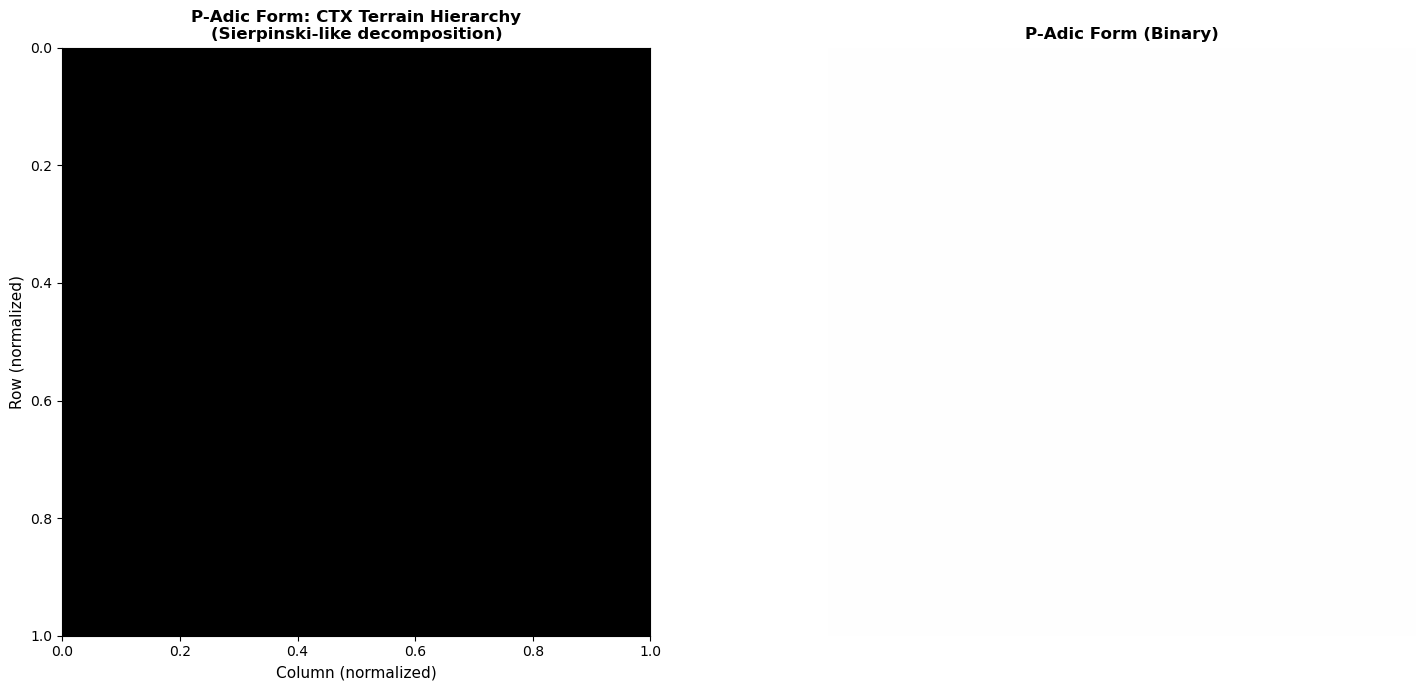

In [5]:
print("Creating p-adic Sierpinski visualization...\n")

fig, (ax_light, ax_dark) = plt.subplots(1, 2, figsize=(16, 7))

# Collect points up to level 11
points = collect_node_points(qtree, level_max=11)

# Light version (blue background, black points)
print("Plotting light version...")
for level in sorted(points.keys()):
    if level <= 11:
        pts = np.array(points[level])
        if len(pts) > 0:
            size = max(0.5, 3 * (1.0 / (2.0 ** (level / 2))))
            alpha = min(1.0, 0.2 + 0.8 * (level / 12))
            ax_light.scatter(pts[:, 0], pts[:, 1], s=size, c='black', alpha=alpha, rasterized=True)
            print(f"  Level {level:2d}: {len(pts):6d} points, size={size:.2f}")

ax_light.set_aspect('equal')
ax_light.set_xlim(0, 1)
ax_light.set_ylim(0, 1)
ax_light.invert_yaxis()
ax_light.set_xlabel('Column (normalized)', fontsize=11)
ax_light.set_ylabel('Row (normalized)', fontsize=11)
ax_light.set_title('P-Adic Form: CTX Terrain Hierarchy\n(Sierpinski-like decomposition)', fontweight='bold', fontsize=12)
ax_light.set_facecolor('lightblue')

# Dark version (black background, white points)
print("\nPlotting dark version...")
for level in sorted(points.keys()):
    if level <= 11:
        pts = np.array(points[level])
        if len(pts) > 0:
            size = max(0.5, 3 * (1.0 / (2.0 ** (level / 2))))
            alpha = min(1.0, 0.2 + 0.8 * (level / 12))
            ax_dark.scatter(pts[:, 0], pts[:, 1], s=size, c='white', alpha=alpha, rasterized=True)

ax_dark.set_aspect('equal')
ax_dark.set_xlim(0, 1)
ax_dark.set_ylim(0, 1)
ax_dark.invert_yaxis()
ax_dark.set_title('P-Adic Form (Binary)', fontweight='bold', fontsize=12)
ax_dark.set_facecolor('black')
for spine in ax_dark.spines.values():
    spine.set_visible(False)
ax_dark.set_xticks([])
ax_dark.set_yticks([])

plt.tight_layout()
plt.savefig('/Volumes/Fangorn/padic_fractal_analysis/padic_sierpinski_v2.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: padic_sierpinski_v2.png")
plt.show()

## Step 5: Progressive Refinement Visualization

Creating progressive refinement visualization...

Panel 1: Levels 0-6...
Panel 2: Levels 0-8...
Panel 3: Levels 0-10...
Panel 4: Levels 0-11...
Panel 5: Levels 0-11...
Panel 6: Levels 0-11...

✓ Saved: padic_progressive_v2.png


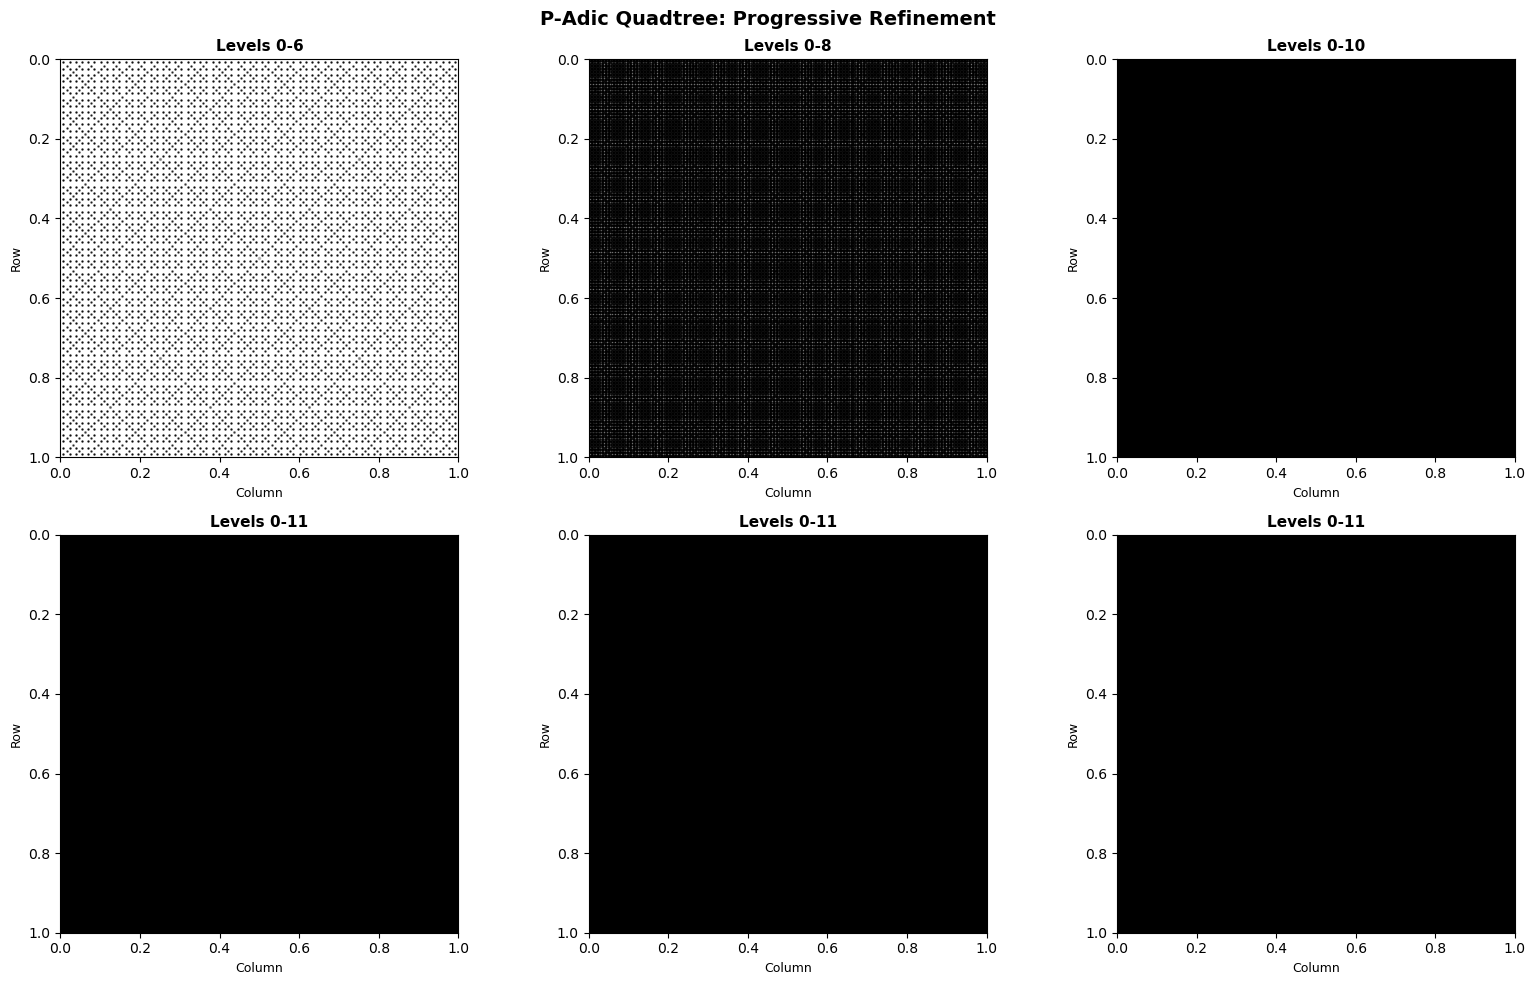

In [6]:
print("Creating progressive refinement visualization...\n")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, level_max in enumerate([6, 8, 10, 11, 12, 13]):
    ax = axes.flat[idx]
    target_level = min(level_max, qtree.max_depth)
    
    points = collect_node_points(qtree, level_max=target_level)
    
    print(f"Panel {idx + 1}: Levels 0-{target_level}...")
    for level in sorted(points.keys()):
        if level <= target_level:
            pts = np.array(points[level])
            if len(pts) > 0:
                size = max(0.5, 2.5 * (1.0 / (2.0 ** (level / 2))))
                alpha = min(1.0, 0.2 + 0.8 * (level / (target_level + 1)))
                ax.scatter(pts[:, 0], pts[:, 1], s=size, c='black', alpha=alpha, rasterized=True)
    
    ax.set_aspect('equal')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.invert_yaxis()
    ax.set_xlabel('Column', fontsize=9)
    ax.set_ylabel('Row', fontsize=9)
    ax.set_title(f'Levels 0-{target_level}', fontweight='bold', fontsize=11)

fig.suptitle('P-Adic Quadtree: Progressive Refinement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Volumes/Fangorn/padic_fractal_analysis/padic_progressive_v2.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: padic_progressive_v2.png")
plt.show()

## Step 6: Multi-Panel Comparison

Creating multi-panel comparison...

Panel 1: P-adic structure (0-10)...
Panel 2: Extended p-adic (0-12)...
Panel 3: Point density...
Panel 4: Original DEM...
Panel 5: Level 4 variance...
Panel 6: Level 4 roughness...

✓ Saved: padic_comparison_v2.png


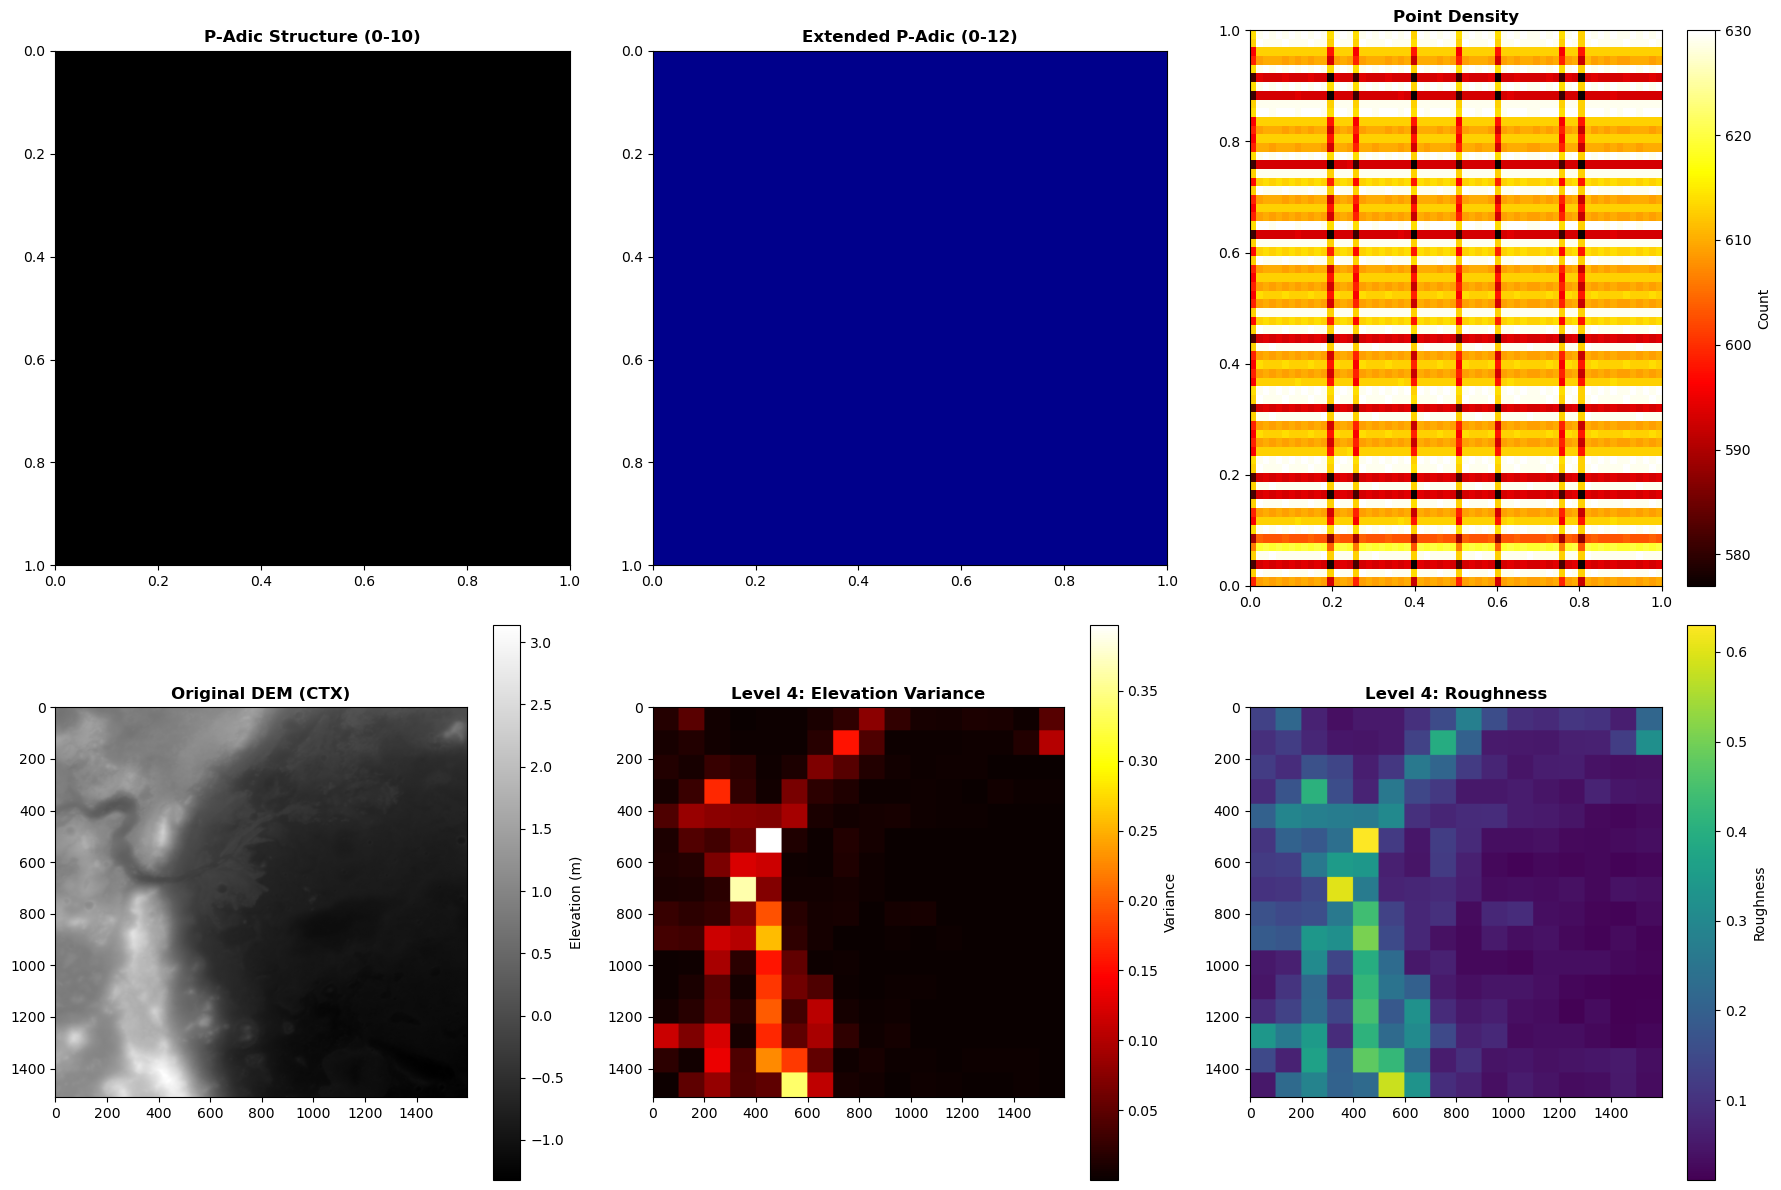

In [7]:
print("Creating multi-panel comparison...\n")

fig = plt.figure(figsize=(18, 12))

# Panel 1: P-adic structure (levels 0-10)
print("Panel 1: P-adic structure (0-10)...")
ax1 = plt.subplot(2, 3, 1)
points1 = collect_node_points(qtree, level_max=10)
for level in sorted(points1.keys()):
    pts = np.array(points1[level])
    if len(pts) > 0:
        size = max(0.5, 2 * (1.0 / (2.0 ** (level / 2))))
        alpha = min(1.0, 0.2 + 0.8 * (level / 11))
        ax1.scatter(pts[:, 0], pts[:, 1], s=size, c='black', alpha=alpha, rasterized=True)
ax1.set_aspect('equal')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.invert_yaxis()
ax1.set_title('P-Adic Structure (0-10)', fontweight='bold')

# Panel 2: Extended (levels 0-12)
print("Panel 2: Extended p-adic (0-12)...")
ax2 = plt.subplot(2, 3, 2)
points2 = collect_node_points(qtree, level_max=12)
for level in sorted(points2.keys()):
    pts = np.array(points2[level])
    if len(pts) > 0:
        size = max(0.3, 1.5 * (1.0 / (2.0 ** (level / 2))))
        alpha = min(1.0, 0.2 + 0.8 * (level / 13))
        ax2.scatter(pts[:, 0], pts[:, 1], s=size, c='darkblue', alpha=alpha, rasterized=True)
ax2.set_aspect('equal')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.invert_yaxis()
ax2.set_title('Extended P-Adic (0-12)', fontweight='bold')

# Panel 3: Density map
print("Panel 3: Point density...")
ax3 = plt.subplot(2, 3, 3)
all_pts = np.vstack([np.array(points2[level]) for level in sorted(points2.keys())])
hist, xedges, yedges = np.histogram2d(all_pts[:, 0], all_pts[:, 1], bins=64)
im3 = ax3.imshow(hist.T, origin='lower', extent=[0, 1, 0, 1], cmap='hot', aspect='auto')
ax3.set_title('Point Density', fontweight='bold')
plt.colorbar(im3, ax=ax3, label='Count')

# Panel 4: Original DEM
print("Panel 4: Original DEM...")
ax4 = plt.subplot(2, 3, 4)
im4 = ax4.imshow(dem_clean, cmap='gray')
ax4.set_title('Original DEM (CTX)', fontweight='bold')
plt.colorbar(im4, ax=ax4, label='Elevation (m)')

# Panel 5: Level 4 variance
print("Panel 5: Level 4 variance...")
ax5 = plt.subplot(2, 3, 5)
try:
    mean_grid, var_grid, rough_grid = qtree.extract_statistics_grid(4)
    im5 = ax5.imshow(var_grid, cmap='hot')
    ax5.set_title('Level 4: Elevation Variance', fontweight='bold')
    plt.colorbar(im5, ax=ax5, label='Variance')
except Exception as e:
    ax5.text(0.5, 0.5, f'Error: {str(e)[:40]}', ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('Level 4 Variance (Error)', fontweight='bold')

# Panel 6: Level 4 roughness
print("Panel 6: Level 4 roughness...")
ax6 = plt.subplot(2, 3, 6)
try:
    im6 = ax6.imshow(rough_grid, cmap='viridis')
    ax6.set_title('Level 4: Roughness', fontweight='bold')
    plt.colorbar(im6, ax=ax6, label='Roughness')
except Exception as e:
    ax6.text(0.5, 0.5, f'Error: {str(e)[:40]}', ha='center', va='center', transform=ax6.transAxes)
    ax6.set_title('Level 4 Roughness (Error)', fontweight='bold')

plt.tight_layout()
plt.savefig('/Volumes/Fangorn/padic_fractal_analysis/padic_comparison_v2.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: padic_comparison_v2.png")
plt.show()

## Summary

In [8]:
print("\n" + "="*80)
print("✓ QUADTREE ANALYSIS AND VISUALIZATION COMPLETE")
print("="*80)

print(f"\nQuadtree Summary:")
print(f"  DEM shape: {dem_clean.shape}")
print(f"  Max depth: {qtree.max_depth}")
print(f"  Total nodes: {total_points}")
print(f"  Root variance: {root.elevation_variance:.6f}")

print(f"\nVisualization Summary:")
print(f"  1. padic_sierpinski_v2.png - Sierpinski-like p-adic form")
print(f"  2. padic_progressive_v2.png - Progressive refinement by level")
print(f"  3. padic_comparison_v2.png - 6-panel comprehensive comparison")

print(f"\nCache:")
print(f"  Quadtree saved: {QUADTREE_CACHE}")
print(f"  DEM saved: {DEM_CACHE}")
print(f"  Reuse with: pickle.load(open('{QUADTREE_CACHE}', 'rb'))")
print("\n" + "="*80)


✓ QUADTREE ANALYSIS AND VISUALIZATION COMPLETE

Quadtree Summary:
  DEM shape: (1512, 1596)
  Max depth: 11
  Total nodes: 2514645
  Root variance: 1.000000

Visualization Summary:
  1. padic_sierpinski_v2.png - Sierpinski-like p-adic form
  2. padic_progressive_v2.png - Progressive refinement by level
  3. padic_comparison_v2.png - 6-panel comprehensive comparison

Cache:
  Quadtree saved: /Volumes/Fangorn/padic_fractal_analysis/cache/quadtree.pkl
  DEM saved: /Volumes/Fangorn/padic_fractal_analysis/cache/dem_clean.npy
  Reuse with: pickle.load(open('/Volumes/Fangorn/padic_fractal_analysis/cache/quadtree.pkl', 'rb'))

